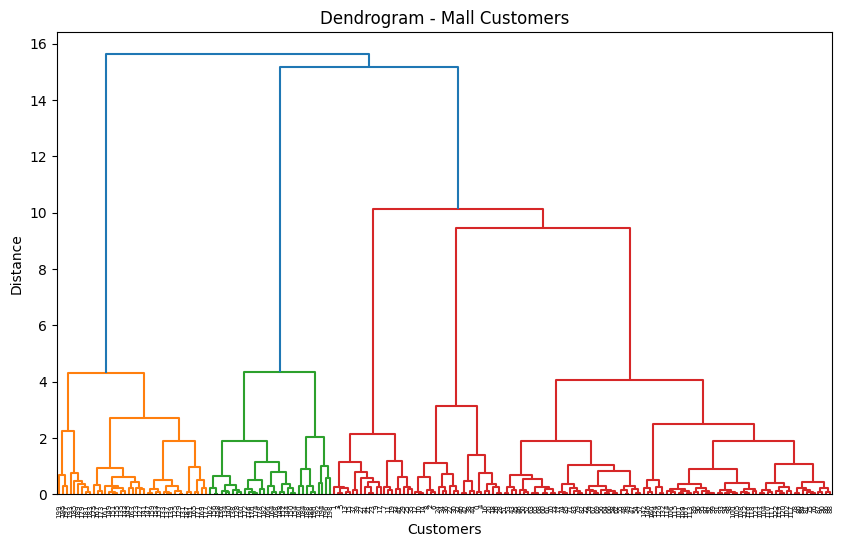

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   Cluster  
0        4  
1        3  
2        4  
3        3  
4        4  


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

# Load dataset (you can download from Kaggle: Mall Customers)
df = pd.read_csv("/kaggle/input/datasets/manaralkhatib/mall-customers/Mall_Customers.csv")

# Select features
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Perform hierarchical clustering
Z = linkage(X_scaled, method='ward')

# Plot dendrogram
plt.figure(figsize=(10,6))
dendrogram(Z)
plt.title("Dendrogram - Mall Customers")
plt.xlabel("Customers")
plt.ylabel("Distance")
plt.show()

# Cut dendrogram to form clusters (e.g., 5 clusters)
clusters = fcluster(Z, t=5, criterion='maxclust')

# Add cluster labels
df['Cluster'] = clusters

print(df.head())

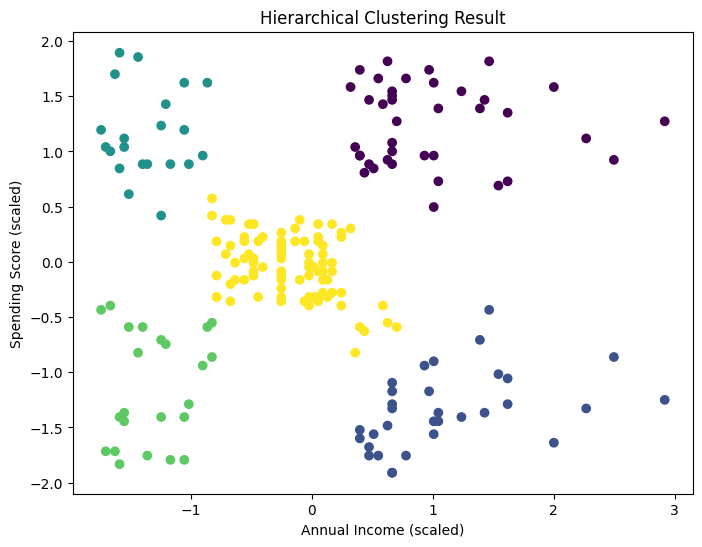

In [7]:
plt.figure(figsize=(8,6))
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=clusters)
plt.xlabel("Annual Income (scaled)")
plt.ylabel("Spending Score (scaled)")
plt.title("Hierarchical Clustering Result")
plt.show()